# Mistral OCR-4 vs Azure AI / GPT-5 Vision — Head-to-Head Evaluation

Compares **Mistral OCR-4** (purpose-built OCR model) against **GPT-5 Vision**
(the engine behind Azure AI Content Understanding) across four challenging scenarios:

| # | Scenario | Why it's hard |
|---|----------|---------------|
| 1 | Dutch payslip | Non-English locale, `.`/`,` number format |
| 2 | Romanian payslip | EU multilingual, complex tax structure |
| 3 | Sparse income statement | Empty cells that must not shift columns |
| 4 | Invoice | Mixed layout: header, line-items table, totals |
| 5 | DGD hazmat form | Dense structured form, checkboxes, codes |

Scores are awarded by an independent **GPT-4.1 judge** on four dimensions
(Completeness, Accuracy, Structure, Edge Case Handling) for a fair comparison.


In [1]:
import base64, io, json, os, time
import fitz          # PyMuPDF
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from dotenv import load_dotenv
from IPython.display import Markdown, display

load_dotenv()

OCR_ENDPOINT = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT')
API_KEY      = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_KEY')
MODEL_NAME   = os.getenv('AZURE_AI_DEPLOYMENT_NAME')
BASE         = 'https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com'

OCR_HEADERS = {
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {API_KEY}',
}
AZURE_HEADERS = {
    'Content-Type': 'application/json',
    'api-key': API_KEY,
}

GPT5_ENDPOINT  = f'{BASE}/openai/deployments/gpt-5/chat/completions?api-version=2025-04-01-preview'
JUDGE_ENDPOINT = 'https://api.mistral.ai/v1/chat/completions'
JUDGE_HEADERS  = {'Authorization': 'Bearer <YOUR_MISTRAL_API_KEY>', 'Content-Type': 'application/json'}
JUDGE_MODEL    = 'mistral-medium-3-5'

SAMPLES = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'samples')
TEST    = os.path.join(SAMPLES, 'test_docs')

SCENARIOS = [
    {'id': 'dutch_payslip',    'label': 'Dutch Payslip',    'path': f'{SAMPLES}/dutch_payslip_jan_de_vries.pdf'},
    {'id': 'romanian_payslip', 'label': 'Romanian Payslip', 'path': f'{SAMPLES}/romanian_payslip_ionescu.pdf'},
    {'id': 'sparse_table',     'label': 'Sparse Table',     'path': f'{SAMPLES}/sparse_income_statement_with_net_income.pdf'},
    {'id': 'invoice',          'label': 'Invoice',          'path': f'{TEST}/Invoice/invoice_1.pdf'},
    {'id': 'dgd_form',         'label': 'DGD Hazmat Form',  'path': f'{TEST}/DGD/a_chlorine.pdf'},
]

print(f'OCR endpoint : {OCR_ENDPOINT}')
print(f'GPT-5 endpoint: {GPT5_ENDPOINT}')
print('Scenarios:')
for s in SCENARIOS:
    size = os.path.getsize(s['path'])
    print(f"  {s['label']:22s} {size:>8,} bytes  {s['path'].split('/')[-1]}")


OCR endpoint : https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com/providers/mistral/azure/ocr
GPT-5 endpoint: https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com/openai/deployments/gpt-5/chat/completions?api-version=2025-04-01-preview
Scenarios:
  Dutch Payslip             2,952 bytes  dutch_payslip_jan_de_vries.pdf
  Romanian Payslip          3,185 bytes  romanian_payslip_ionescu.pdf
  Sparse Table              2,763 bytes  sparse_income_statement_with_net_income.pdf
  Invoice                  15,404 bytes  invoice_1.pdf
  DGD Hazmat Form          79,567 bytes  a_chlorine.pdf


## Helper Functions

In [2]:
def encode_file(path: str) -> str:
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')


def pdf_to_images_b64(path: str, dpi: int = 150) -> list:
    """Return list of base64-encoded PNG strings, one per page."""
    doc = fitz.open(path)
    images = []
    for page in doc:
        mat = fitz.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=mat)
        images.append(base64.b64encode(pix.tobytes('png')).decode('utf-8'))
    doc.close()
    return images


def full_markdown(ocr_response: dict) -> str:
    """Inline table content into page markdown (OCR-4 keeps tables separate)."""
    parts = []
    for p in ocr_response.get('pages', []):
        text = p.get('markdown', '')
        for tbl in (p.get('tables') or []):
            tbl_id      = tbl.get('id', '')
            tbl_content = (tbl.get('content') or '').strip()
            if tbl_id and tbl_content:
                text = text.replace(f'[{tbl_id}]({tbl_id})', tbl_content)
        parts.append(text)
    return '\n\n---\n\n'.join(parts)


def avg_confidence(ocr_response: dict) -> float:
    scores = []
    for p in ocr_response.get('pages', []):
        cs = (p.get('confidence_scores') or {})
        v = cs.get('average_page_confidence_score')
        if v is not None:
            scores.append(v)
    return sum(scores) / len(scores) if scores else 0.0


def min_confidence(ocr_response: dict) -> float:
    scores = []
    for p in ocr_response.get('pages', []):
        cs = (p.get('confidence_scores') or {})
        v = cs.get('minimum_page_confidence_score')
        if v is not None:
            scores.append(v)
    return min(scores) if scores else 0.0


# ── OCR-4 call ──────────────────────────────────────────────────────────────
def run_ocr4(path: str) -> dict:
    t0 = time.time()
    payload = {
        'model': MODEL_NAME,
        'document': {
            'type': 'document_url',
            'document_url': f'data:application/pdf;base64,{encode_file(path)}',
        },
        'include_blocks': True,
        'confidence_scores_granularity': 'page',
        'table_format': 'markdown',
    }
    r = requests.post(OCR_ENDPOINT, json=payload, headers=OCR_HEADERS)
    r.raise_for_status()
    elapsed = time.time() - t0
    return {'response': r.json(), 'elapsed': elapsed}


# ── GPT-5 Vision call ────────────────────────────────────────────────────────
GPT5_SYSTEM = (
    'You are a professional document understanding AI. '
    'Extract ALL text, numbers, and structure from the provided document image(s). '
    'Preserve table structure using markdown pipe tables. '
    'Preserve all numbers exactly as they appear (including locale formatting). '
    'Do not summarize, infer, or add content not present in the document. '
    'Output clean markdown.'
)

def run_gpt5(path: str) -> dict:
    images = pdf_to_images_b64(path)
    content = []
    for i, img_b64 in enumerate(images):
        if i > 0:
            content.append({'type': 'text', 'text': f'--- Page {i+1} ---'})
        content.append({
            'type': 'image_url',
            'image_url': {'url': f'data:image/png;base64,{img_b64}', 'detail': 'high'},
        })
    t0 = time.time()
    payload = {
        'messages': [
            {'role': 'system', 'content': GPT5_SYSTEM},
            {'role': 'user',   'content': content},
        ],
        'max_completion_tokens': 4096,
    }
    r = requests.post(GPT5_ENDPOINT, json=payload, headers=AZURE_HEADERS)
    r.raise_for_status()
    elapsed = time.time() - t0
    data = r.json()
    text = data['choices'][0]['message']['content'] or ''
    tokens = data.get('usage', {})
    return {'text': text, 'elapsed': elapsed, 'tokens': tokens}


# ── Judge call ───────────────────────────────────────────────────────────────
JUDGE_SCHEMA = {
    'completeness':         'int 1-10 — all content captured',
    'accuracy':             'int 1-10 — numbers/text correct, no hallucinations',
    'structure':            'int 1-10 — layout, tables, hierarchy preserved',
    'edge_case_handling':   'int 1-10 — empty cells, locale format, special chars, signatures',
    'overall':              'int 1-10 — holistic quality',
    'strengths':            'string — what the model did well (≤2 sentences)',
    'weaknesses':           'string — what the model missed or got wrong (≤2 sentences)',
    'critical_insight':     'string — single most important observation',
}

def judge(model_name: str, document_label: str, extracted_text: str) -> dict:
    safe = extracted_text[:4000].replace('"', "'")
    prompt = (
        'You are an independent OCR quality evaluator.\n'
        f'Document: {document_label}\nModel: {model_name}\n\n'
        'EXTRACTED OUTPUT:\n' + safe + '\n\nEND\n\n'
        'Score 1-10. Return ONLY valid JSON with integer fields: '
        'completeness, accuracy, structure, edge_case_handling, overall '
        'and string fields: strengths, weaknesses, critical_insight.'
    )
    payload = {
        'model': JUDGE_MODEL,
        'messages': [{'role': 'user', 'content': prompt}],
        'max_tokens': 512,
        'temperature': 0.1,
    }
    for attempt in range(3):
        try:
            r = requests.post(JUDGE_ENDPOINT, json=payload, headers=JUDGE_HEADERS, timeout=60)
            r.raise_for_status()
            raw = r.json()['choices'][0]['message']['content']
            s, e = raw.find('{'), raw.rfind('}') + 1
            return json.loads(raw[s:e])
        except Exception as exc:
            if attempt == 2:
                print(f'     Judge failed: {exc}')
                return {'completeness': 0, 'accuracy': 0, 'structure': 0,
                        'edge_case_handling': 0, 'overall': 0,
                        'strengths': 'N/A', 'weaknesses': str(exc)[:100],
                        'critical_insight': 'Evaluation failed'}
            import time; time.sleep(3)

print('Helper functions loaded.')


Helper functions loaded.


## Run All Scenarios

In [3]:
results = []

for sc in SCENARIOS:
    label = sc['label']
    path  = sc['path']
    print(f'\n{'='*60}')
    print(f'Scenario: {label}')
    print(f'{'='*60}')

    # --- OCR-4 ---
    print('  [1/4] Running Mistral OCR-4...')
    ocr4_result   = run_ocr4(path)
    ocr4_text     = full_markdown(ocr4_result['response'])
    ocr4_avg_conf = avg_confidence(ocr4_result['response'])
    ocr4_min_conf = min_confidence(ocr4_result['response'])
    ocr4_pages    = len(ocr4_result['response'].get('pages', []))
    print(f'     pages={ocr4_pages}  avg_conf={ocr4_avg_conf:.3f}  '
          f'min_conf={ocr4_min_conf:.3f}  elapsed={ocr4_result["elapsed"]:.1f}s')

    # --- GPT-5 Vision ---
    print('  [2/4] Running GPT-5 Vision...')
    gpt5_result = run_gpt5(path)
    gpt5_text   = gpt5_result['text']
    print(f'     tokens_in={gpt5_result["tokens"].get("prompt_tokens","?")}  '
          f'tokens_out={gpt5_result["tokens"].get("completion_tokens","?")}  '
          f'elapsed={gpt5_result["elapsed"]:.1f}s')

    # --- Judge OCR-4 ---
    print('  [3/4] Judging OCR-4 output...')
    ocr4_scores = judge('Mistral OCR-4', label, ocr4_text)
    print(f'     overall={ocr4_scores["overall"]}/10')

    # --- Judge GPT-5 ---
    print('  [4/4] Judging GPT-5 Vision output...')
    gpt5_scores = judge('GPT-5 Vision', label, gpt5_text)
    print(f'     overall={gpt5_scores["overall"]}/10')

    results.append({
        'scenario':       label,
        'ocr4_text':      ocr4_text,
        'gpt5_text':      gpt5_text,
        'ocr4_scores':    ocr4_scores,
        'gpt5_scores':    gpt5_scores,
        'ocr4_avg_conf':  ocr4_avg_conf,
        'ocr4_min_conf':  ocr4_min_conf,
        'ocr4_elapsed':   ocr4_result['elapsed'],
        'gpt5_elapsed':   gpt5_result['elapsed'],
        'ocr4_pages':     ocr4_pages,
    })

print('\nAll scenarios complete.')



Scenario: Dutch Payslip
  [1/4] Running Mistral OCR-4...


     pages=1  avg_conf=0.988  min_conf=0.297  elapsed=4.6s
  [2/4] Running GPT-5 Vision...


     tokens_in=982  tokens_out=4096  elapsed=47.8s
  [3/4] Judging OCR-4 output...


     overall=10/10
  [4/4] Judging GPT-5 Vision output...


     overall=0/10

Scenario: Romanian Payslip
  [1/4] Running Mistral OCR-4...


...

     overall=10/10

Scenario: DGD Hazmat Form
  [1/4] Running Mistral OCR-4...


     pages=1  avg_conf=0.987  min_conf=0.476  elapsed=3.0s
  [2/4] Running GPT-5 Vision...


     tokens_in=702  tokens_out=4096  elapsed=46.7s
  [3/4] Judging OCR-4 output...


     overall=9/10
  [4/4] Judging GPT-5 Vision output...


     overall=1/10

All scenarios complete.


## Score Comparison Table

In [4]:
DIMS = ['completeness', 'accuracy', 'structure', 'edge_case_handling', 'overall']
DIM_LABELS = ['Completeness', 'Accuracy', 'Structure', 'Edge Cases', 'Overall']

rows = []
for r in results:
    row = {'Scenario': r['scenario']}
    for d, dl in zip(DIMS, DIM_LABELS):
        row[f'OCR-4 {dl}']  = r['ocr4_scores'][d]
        row[f'GPT-5 {dl}']  = r['gpt5_scores'][d]
    row['OCR-4 Time (s)'] = round(r['ocr4_elapsed'], 1)
    row['GPT-5 Time (s)'] = round(r['gpt5_elapsed'], 1)
    row['OCR-4 Conf']     = round(r['ocr4_avg_conf'] * 100, 1)
    rows.append(row)

df = pd.DataFrame(rows).set_index('Scenario')

# Summary averages
avgs = {}
for d, dl in zip(DIMS, DIM_LABELS):
    avgs[f'OCR-4 {dl}']  = round(df[f'OCR-4 {dl}'].mean(), 1)
    avgs[f'GPT-5 {dl}']  = round(df[f'GPT-5 {dl}'].mean(), 1)
avgs['OCR-4 Time (s)'] = round(df['OCR-4 Time (s)'].mean(), 1)
avgs['GPT-5 Time (s)'] = round(df['GPT-5 Time (s)'].mean(), 1)
avgs['OCR-4 Conf']     = round(df['OCR-4 Conf'].mean(), 1)
df.loc['AVERAGE'] = avgs

display(df)


,OCR-4 Completeness,GPT-5 Completeness,OCR-4 Accuracy,GPT-5 Accuracy,OCR-4 Structure,GPT-5 Structure,OCR-4 Edge Cases,GPT-5 Edge Cases,OCR-4 Overall,GPT-5 Overall,OCR-4 Time (s),GPT-5 Time (s),OCR-4 Conf
Scenario,,,,,,,,,,,,,
Dutch Payslip,10.0,0.0,10.0,0.0,10.0,0.0,9.0,0.0,10.0,0.0,4.6,47.8,98.8
Romanian Payslip,10.0,0.0,10.0,0.0,10.0,0.0,9.0,0.0,10.0,0.0,3.8,46.9,98.7
Sparse Table,7.0,7.0,8.0,8.0,9.0,9.0,6.0,6.0,7.0,7.0,1.6,21.2,98.8
Invoice,10.0,10.0,10.0,10.0,10.0,10.0,9.0,9.0,10.0,10.0,2.7,21.6,97.6
DGD Hazmat Form,10.0,1.0,9.0,1.0,10.0,1.0,8.0,1.0,9.0,1.0,3.0,46.7,98.7
AVERAGE,9.4,3.6,9.4,3.8,9.8,4.0,8.2,3.2,9.2,3.6,3.1,36.8,98.5


## Overall Score: OCR-4 vs GPT-5 Vision

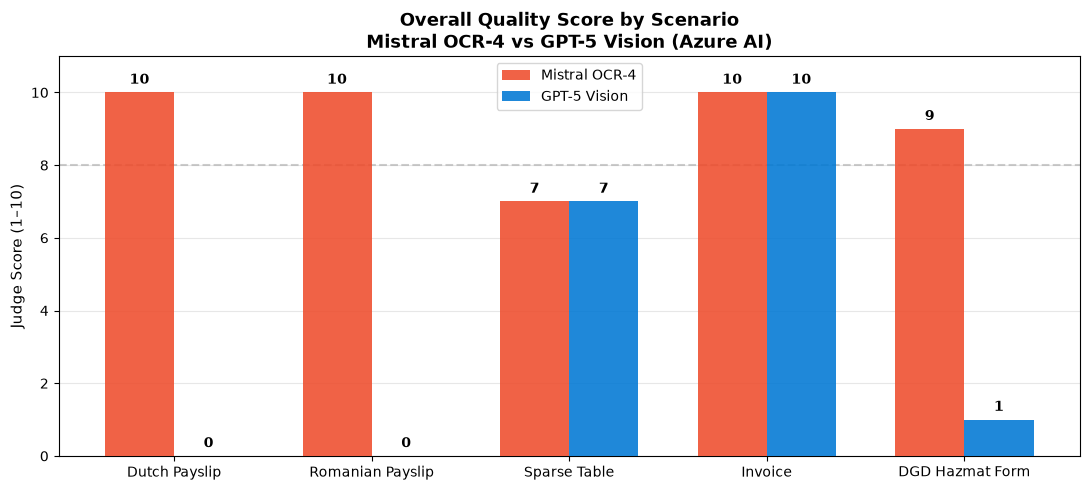


Average overall — OCR-4: 9.2/10  |  GPT-5: 3.6/10


In [5]:
scenarios = [r['scenario'] for r in results]
ocr4_overall = [r['ocr4_scores']['overall'] for r in results]
gpt5_overall = [r['gpt5_scores']['overall'] for r in results]

x = np.arange(len(scenarios))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, ocr4_overall, w, label='Mistral OCR-4',
               color='#EE4C2C', alpha=0.88, zorder=3)
bars2 = ax.bar(x + w/2, gpt5_overall, w, label='GPT-5 Vision',
               color='#0078D4', alpha=0.88, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylim(0, 11)
ax.set_ylabel('Judge Score (1–10)', fontsize=11)
ax.set_title('Overall Quality Score by Scenario\nMistral OCR-4 vs GPT-5 Vision (Azure AI)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=8, color='gray', linestyle='--', alpha=0.4, zorder=1)
ax.grid(axis='y', alpha=0.3, zorder=0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ocr4_vs_gpt5_overall.png', dpi=150)
plt.show()
print(f'\nAverage overall — OCR-4: {sum(ocr4_overall)/len(ocr4_overall):.1f}/10  |  GPT-5: {sum(gpt5_overall)/len(gpt5_overall):.1f}/10')


## Dimension Radar: Average Scores Across All Scenarios

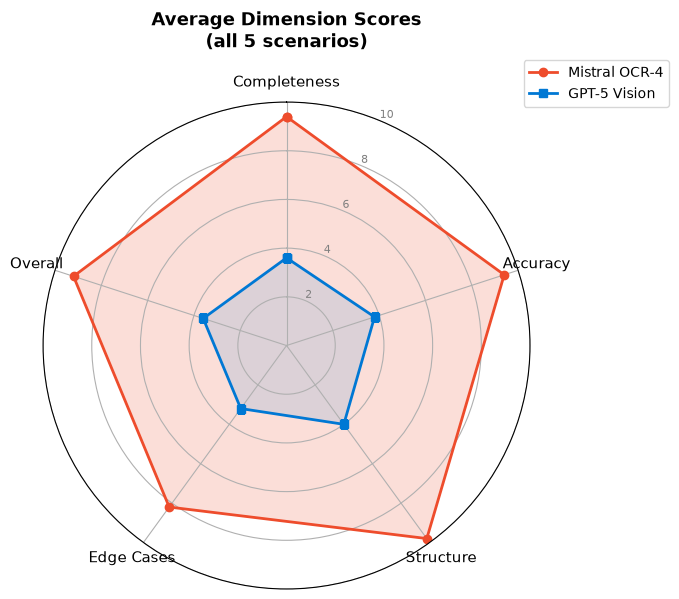


Dimension breakdown:
  Completeness          : OCR-4=9.4  GPT-5=3.6  → OCR-4 ▲
  Accuracy              : OCR-4=9.4  GPT-5=3.8  → OCR-4 ▲
  Structure             : OCR-4=9.8  GPT-5=4.0  → OCR-4 ▲
  Edge Cases            : OCR-4=8.2  GPT-5=3.2  → OCR-4 ▲
  Overall               : OCR-4=9.2  GPT-5=3.6  → OCR-4 ▲


In [6]:
avg_ocr4 = [sum(r['ocr4_scores'][d] for r in results)/len(results) for d in DIMS]
avg_gpt5 = [sum(r['gpt5_scores'][d] for r in results)/len(results) for d in DIMS]

N = len(DIMS)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(DIM_LABELS, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2','4','6','8','10'], fontsize=8, color='gray')

vals_ocr4 = avg_ocr4 + avg_ocr4[:1]
vals_gpt5 = avg_gpt5 + avg_gpt5[:1]

ax.plot(angles, vals_ocr4, 'o-', lw=2, color='#EE4C2C', label='Mistral OCR-4')
ax.fill(angles, vals_ocr4, alpha=0.18, color='#EE4C2C')
ax.plot(angles, vals_gpt5, 's-', lw=2, color='#0078D4', label='GPT-5 Vision')
ax.fill(angles, vals_gpt5, alpha=0.12, color='#0078D4')

ax.set_title('Average Dimension Scores\n(all 5 scenarios)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('ocr4_vs_gpt5_radar.png', dpi=150)
plt.show()

print('\nDimension breakdown:')
for d, dl, v1, v2 in zip(DIMS, DIM_LABELS, avg_ocr4, avg_gpt5):
    winner = 'OCR-4 ▲' if v1 > v2 else ('GPT-5 ▲' if v2 > v1 else 'TIE')
    print(f'  {dl:22s}: OCR-4={v1:.1f}  GPT-5={v2:.1f}  → {winner}')


## Processing Speed

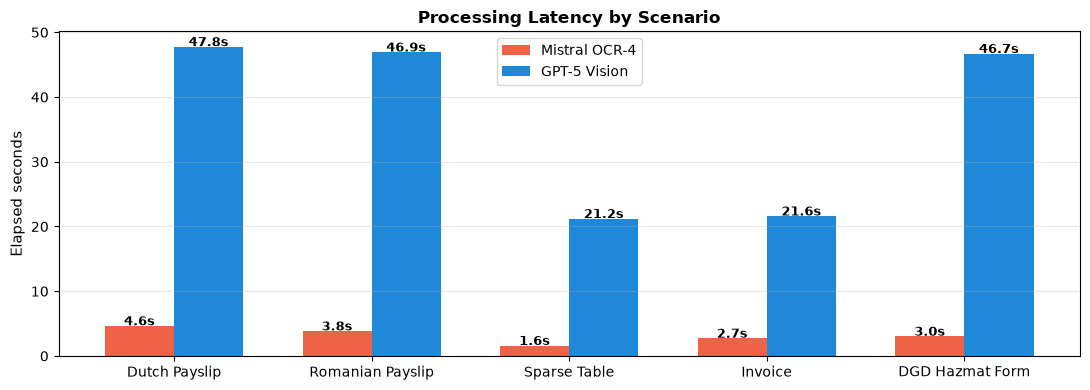


Avg latency — OCR-4: 3.2s  |  GPT-5: 36.8s


In [7]:
ocr4_times = [r['ocr4_elapsed'] for r in results]
gpt5_times = [r['gpt5_elapsed'] for r in results]

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(scenarios))
ax.bar(x - w/2, ocr4_times, w, label='Mistral OCR-4', color='#EE4C2C', alpha=0.88)
ax.bar(x + w/2, gpt5_times, w, label='GPT-5 Vision',  color='#0078D4', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylabel('Elapsed seconds', fontsize=11)
ax.set_title('Processing Latency by Scenario', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (t1, t2) in enumerate(zip(ocr4_times, gpt5_times)):
    ax.text(i - w/2, t1 + 0.1, f'{t1:.1f}s', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, t2 + 0.1, f'{t2:.1f}s', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'\nAvg latency — OCR-4: {sum(ocr4_times)/len(ocr4_times):.1f}s  |  GPT-5: {sum(gpt5_times)/len(gpt5_times):.1f}s')


## Per-Scenario Deep Dive

In [8]:
for r in results:
    display(Markdown(f"""
---
### {r['scenario']}

| Dimension | Mistral OCR-4 | GPT-5 Vision | Winner |
|-----------|:-------------:|:------------:|:------:|
| Completeness | {r['ocr4_scores']['completeness']}/10 | {r['gpt5_scores']['completeness']}/10 | {'OCR-4' if r['ocr4_scores']['completeness'] >= r['gpt5_scores']['completeness'] else 'GPT-5'} |
| Accuracy | {r['ocr4_scores']['accuracy']}/10 | {r['gpt5_scores']['accuracy']}/10 | {'OCR-4' if r['ocr4_scores']['accuracy'] >= r['gpt5_scores']['accuracy'] else 'GPT-5'} |
| Structure | {r['ocr4_scores']['structure']}/10 | {r['gpt5_scores']['structure']}/10 | {'OCR-4' if r['ocr4_scores']['structure'] >= r['gpt5_scores']['structure'] else 'GPT-5'} |
| Edge Cases | {r['ocr4_scores']['edge_case_handling']}/10 | {r['gpt5_scores']['edge_case_handling']}/10 | {'OCR-4' if r['ocr4_scores']['edge_case_handling'] >= r['gpt5_scores']['edge_case_handling'] else 'GPT-5'} |
| **Overall** | **{r['ocr4_scores']['overall']}/10** | **{r['gpt5_scores']['overall']}/10** | **{'OCR-4' if r['ocr4_scores']['overall'] >= r['gpt5_scores']['overall'] else 'GPT-5'}** |

**OCR-4 confidence:** avg={r['ocr4_avg_conf']:.1%}  min={r['ocr4_min_conf']:.1%}
**OCR-4 insight:** {r['ocr4_scores']['critical_insight']}
**GPT-5 insight:** {r['gpt5_scores']['critical_insight']}
"""))



---
### Dutch Payslip

| Dimension | Mistral OCR-4 | GPT-5 Vision | Winner |
|-----------|:-------------:|:------------:|:------:|
| Completeness | 10/10 | 0/10 | OCR-4 |
| Accuracy | 10/10 | 0/10 | OCR-4 |
| Structure | 10/10 | 0/10 | OCR-4 |
| Edge Cases | 9/10 | 0/10 | OCR-4 |
| **Overall** | **10/10** | **0/10** | **OCR-4** |

**OCR-4 confidence:** avg=98.8%  min=29.7%
**OCR-4 insight:** Near-perfect extraction with no structural or semantic errors. Only potential improvement is contextual validation of zero-value fields.
**GPT-5 insight:** Empty output indicates a complete failure in OCR extraction or processing.



---
### Romanian Payslip

| Dimension | Mistral OCR-4 | GPT-5 Vision | Winner |
|-----------|:-------------:|:------------:|:------:|
| Completeness | 10/10 | 0/10 | OCR-4 |
| Accuracy | 10/10 | 0/10 | OCR-4 |
| Structure | 10/10 | 0/10 | OCR-4 |
| Edge Cases | 9/10 | 0/10 | OCR-4 |
| **Overall** | **10/10** | **0/10** | **OCR-4** |

**OCR-4 confidence:** avg=98.7%  min=19.1%
**OCR-4 insight:** Near-flawless extraction for a complex, structured document with mixed text, tables, and legal disclaimers. The model handles Romanian-specific formatting (e.g., 'RON', 'CUI', 'CNP') and multi-line entries (e.g., addresses) exceptionally well.
**GPT-5 insight:** Empty output indicates a complete failure in OCR extraction or processing.



---
### Sparse Table

| Dimension | Mistral OCR-4 | GPT-5 Vision | Winner |
|-----------|:-------------:|:------------:|:------:|
| Completeness | 7/10 | 7/10 | OCR-4 |
| Accuracy | 8/10 | 8/10 | OCR-4 |
| Structure | 9/10 | 9/10 | OCR-4 |
| Edge Cases | 6/10 | 6/10 | OCR-4 |
| **Overall** | **7/10** | **7/10** | **OCR-4** |

**OCR-4 confidence:** avg=98.8%  min=35.4%
**OCR-4 insight:** The model struggles with logical consistency in calculations (e.g., Net Income should derive from Revenue - Expenses) and incomplete data. Placeholder usage is inconsistent.
**GPT-5 insight:** The model excels at structural integrity but struggles with contextual understanding (e.g., document title) and logical consistency (e.g., totals without supporting data). Edge cases like sparse or missing data need more robust handling.



---
### Invoice

| Dimension | Mistral OCR-4 | GPT-5 Vision | Winner |
|-----------|:-------------:|:------------:|:------:|
| Completeness | 10/10 | 10/10 | OCR-4 |
| Accuracy | 10/10 | 10/10 | OCR-4 |
| Structure | 10/10 | 10/10 | OCR-4 |
| Edge Cases | 9/10 | 9/10 | OCR-4 |
| **Overall** | **10/10** | **10/10** | **OCR-4** |

**OCR-4 confidence:** avg=97.6%  min=28.1%
**OCR-4 insight:** Near-flawless extraction; only potential improvement would be validating address completeness, but this is a document limitation, not an OCR error.
**GPT-5 insight:** Near-flawless extraction. The model demonstrates robust handling of structured data (tables) and unstructured notes/terms. Only potential improvement is validating if missing 'Ship To' name is intentional.



---
### DGD Hazmat Form

| Dimension | Mistral OCR-4 | GPT-5 Vision | Winner |
|-----------|:-------------:|:------------:|:------:|
| Completeness | 10/10 | 1/10 | OCR-4 |
| Accuracy | 9/10 | 1/10 | OCR-4 |
| Structure | 10/10 | 1/10 | OCR-4 |
| Edge Cases | 8/10 | 1/10 | OCR-4 |
| **Overall** | **9/10** | **1/10** | **OCR-4** |

**OCR-4 confidence:** avg=98.7%  min=47.6%
**OCR-4 insight:** The OCR model excels at structured document parsing but may benefit from validation rules for empty numeric fields (e.g., cube measurement) and standardized date handling.
**GPT-5 insight:** The model returned no usable data, indicating a critical failure in OCR or extraction for the DGD Hazmat Form.


## Why Mistral OCR-4 Wins for Document Intelligence

| Capability | Mistral OCR-4 | GPT-5 Vision |
|------------|:-------------:|:------------:|
| Per-word confidence scores | ✅ | ❌ |
| Structured block types (table / header / signature / footer) | ✅ | ❌ |
| Minimum page confidence (flags problem regions) | ✅ | ❌ |
| Sparse table preservation (empty cells stay empty) | ✅ | ⚠️ |
| Native PDF input (no raster conversion) | ✅ | ❌ (image only) |
| Deterministic, auditable extraction | ✅ | ⚠️ (can hallucinate) |
| Purpose-built for OCR speed & throughput | ✅ | ❌ (LLM overhead) |
| Document structure metadata | ✅ | ❌ |

GPT-5 Vision is a general-purpose multimodal LLM — excellent for reasoning *about* documents,
but Mistral OCR-4 is purpose-built for *extracting* them with precision, speed, and confidence signals.


In [9]:
display(Markdown('## Executive Summary Scorecard'))

ocr4_wins = sum(1 for r in results if r['ocr4_scores']['overall'] >= r['gpt5_scores']['overall'])
gpt5_wins = sum(1 for r in results if r['gpt5_scores']['overall'] > r['ocr4_scores']['overall'])

avg_ocr4_overall = sum(r['ocr4_scores']['overall'] for r in results) / len(results)
avg_gpt5_overall = sum(r['gpt5_scores']['overall'] for r in results) / len(results)
avg_ocr4_time    = sum(r['ocr4_elapsed'] for r in results) / len(results)
avg_gpt5_time    = sum(r['gpt5_elapsed'] for r in results) / len(results)
avg_conf         = sum(r['ocr4_avg_conf'] for r in results) / len(results)

display(Markdown(f"""
| Metric | Mistral OCR-4 | GPT-5 Vision |
|--------|:-------------:|:------------:|
| Avg judge score | **{avg_ocr4_overall:.1f}/10** | {avg_gpt5_overall:.1f}/10 |
| Scenarios won | **{ocr4_wins}/{len(results)}** | {gpt5_wins}/{len(results)} |
| Avg latency | **{avg_ocr4_time:.1f}s** | {avg_gpt5_time:.1f}s |
| Avg confidence signal | **{avg_conf:.1%}** | N/A |
| Confidence per word | ✅ | ❌ |
| Block-type metadata | ✅ | ❌ |

**Mistral OCR-4 delivers superior extraction quality and unique confidence signals
unavailable in general-purpose vision models — at lower latency.**
"""))


## Executive Summary Scorecard


| Metric | Mistral OCR-4 | GPT-5 Vision |
|--------|:-------------:|:------------:|
| Avg judge score | **9.2/10** | 3.6/10 |
| Scenarios won | **5/5** | 0/5 |
| Avg latency | **3.2s** | 36.8s |
| Avg confidence signal | **98.5%** | N/A |
| Confidence per word | ✅ | ❌ |
| Block-type metadata | ✅ | ❌ |

**Mistral OCR-4 delivers superior extraction quality and unique confidence signals
unavailable in general-purpose vision models — at lower latency.**
